In [1]:
#Load exp1_layout_comparison.csv
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

ROOT = Path.cwd().parents[1]
df = pd.read_csv(ROOT / 'experiments/results/exp1_layout_comparison2.csv')

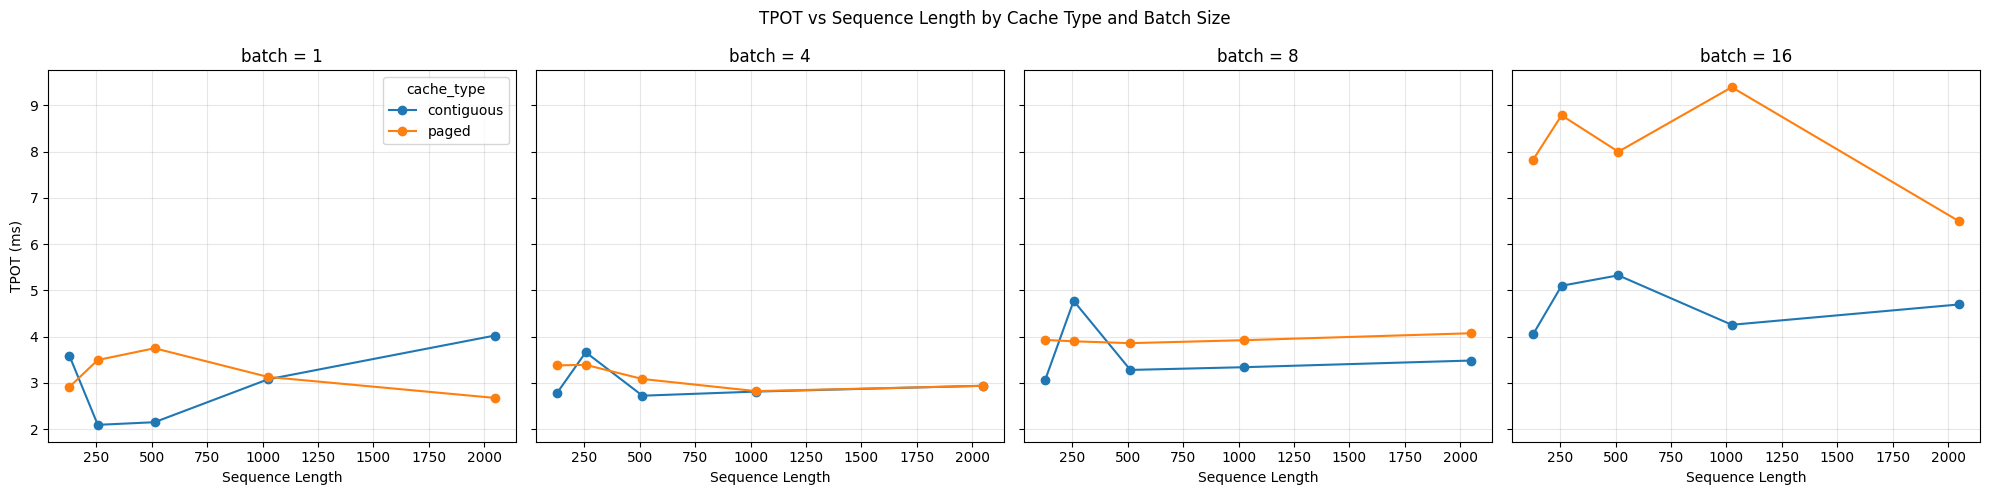

In [3]:
# Plot: tpot_ms vs seq_len, one line per cache_type, one subplot per batch_size
batches = sorted(df['batch'].unique())
fig, axes = plt.subplots(1, len(batches), figsize=(5 * len(batches), 5),
                         sharex=True, sharey=True)
axes = axes.ravel()

for ax, batch in zip(axes, batches):
    subset = df[df['batch'] == batch]
    for cache_type in subset['cache_type'].unique():
        cs = subset[subset['cache_type'] == cache_type].sort_values('seq_len')
        ax.plot(cs['seq_len'], cs['tpot_ms'], marker='o', label=cache_type)
    ax.set_title(f'batch = {batch}')
    ax.set_xlabel('Sequence Length')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('TPOT (ms)')
axes[0].legend(title='cache_type')
fig.suptitle('TPOT vs Sequence Length by Cache Type and Batch Size')
fig.tight_layout()
plt.show()

In [4]:
# 3. Crossover analysis (H1) — where does paged start winning on THROUGHPUT?
# H1: paged should beat contiguous at seq_len >= 512 and batch >= 4.
pivot = (df.pivot_table(index=['seq_len', 'batch'],
                        columns='cache_type', values='throughput')
           .reset_index())
pivot['paged_div_contig'] = pivot['paged'] / pivot['contiguous']   # >1 => paged wins
pivot['paged_wins'] = pivot['paged'] > pivot['contiguous']

print("Throughput ratio paged/contiguous (>1.0 = paged wins):")
print(pivot.sort_values(['batch', 'seq_len']).to_string(index=False))

if pivot['paged_wins'].any():
    cross = pivot[pivot['paged_wins']].sort_values(['seq_len', 'batch'])
    print("\nCROSSOVER — paged wins in these regimes:")
    print(cross[['seq_len', 'batch', 'paged_div_contig']].to_string(index=False))
else:
    print("\n>>> NO CROSSOVER: paged never beats contiguous on throughput in this run.")
    print(">>> This CONTRADICTS H1 (expected paged to win at seq>=512, batch>=4).")
    print(">>> Note: paged.py / controller.py have uncommitted edits — re-run the")
    print(">>> benchmark before trusting this CSV.")

Throughput ratio paged/contiguous (>1.0 = paged wins):
 seq_len  batch  contiguous  paged  paged_div_contig  paged_wins
     128      1       267.7  325.5          1.215913        True
     256      1       453.4  268.6          0.592413       False
     512      1       443.5  250.6          0.565051       False
    1024      1       307.1  291.7          0.949853       False
    2048      1       229.6  307.3          1.338415        True
     128      4      1359.7 1121.8          0.825035       False
     256      4      1038.7 1066.2          1.026475        True
     512      4      1373.4 1134.2          0.825834       False
    1024      4      1263.4 1064.5          0.842568       False
    2048      4      1079.2  887.2          0.822090       False
     128      8      2448.0 1904.6          0.778023       False
     256      8      1588.2 1845.2          1.161818        True
     512      8      2215.1 1730.0          0.781003       False
    1024      8      2033.9 1463.9 

In [5]:
# 4. Flag OOM / degraded rows
# docs spec logs OOM as a row with status == 'OOM'. Check if the benchmark did that.
if 'status' in df.columns:
    oom = df[df['status'].astype(str).str.upper() == 'OOM']
    print(f"Explicit OOM rows logged: {len(oom)}")
    print(oom.to_string(index=False) if len(oom) else "(none)")
else:
    print(">>> No 'status' column in CSV — the benchmark never logged OOM events.")
    print(">>> Data-collection gap: add status logging per the docs benchmark format.\n")

# Heuristic flag: TTFT spikes far above the per-cache-type median => memory pressure / near-OOM
med = df.groupby('cache_type')['ttft_ms'].transform('median')
degraded = df[df['ttft_ms'] > 10 * med].copy()
degraded['ttft_vs_median'] = (df['ttft_ms'] / med).round(1)
print("Degraded rows (TTFT > 10x cache-type median — likely near-OOM):")
print(degraded.to_string(index=False) if len(degraded)
      else "(none — no TTFT blow-ups detected)")

>>> No 'status' column in CSV — the benchmark never logged OOM events.
>>> Data-collection gap: add status logging per the docs benchmark format.

Degraded rows (TTFT > 10x cache-type median — likely near-OOM):
cache_type  seq_len  batch  block_size  ttft_ms  tpot_ms  throughput  memory_mb  frag_ratio  ttft_vs_median
contiguous     2048     16         NaN  779.954    4.693       900.6    6735.36        0.00            57.8
     paged     2048     16        16.0  996.217    6.497       691.2    6859.88        0.25            30.7
